# **Histogram**

You can consider a **histogram** as a graph or plot that gives you an overall idea about the **intensity distribution** of an image.

- A histogram is a plot with:
  - **X-axis:** Pixel values (ranging from 0 to 255, not always)
  - **Y-axis:** Number of pixels in the image with that intensity
- By looking at the histogram, you can get intuition about:
  - **Contrast**
  - **Brightness**
  - **Intensity distribution**
  - …etc.

![image-0.png](../Histogram_Processing/Images/0_0_image.png)

> *(This histogram is for a grayscale image, not a color image.)*

- **Left region of histogram:** Shows darker pixels  
- **Right region of histogram:** Shows brighter pixels  

Observations:  
- Dark regions dominate over bright regions  
- Midtones (around value 127) are very few

---

## **Histogram Processing**

### Definitions

- **Digital image with L intensity levels:** $$f(x, y)$$
- **Unnormalized histogram:** counts how many pixels have a given intensity. For intensity level $(r_k)$:  

$$ h(r_k) = n_k $$
  - for $r_k = 0, 1, 2, ..., L-1$
  - Each intensity level corresponds to a **histogram bin**.

- **Normalized histogram:** fraction of pixels with a given intensity:  

$$p(r_k) = \frac{h(r_k)}{M \times N}$$
  - $M$ = number of rows, $N$ = number of columns in the image
  - Sum of all  $p(r_k)$ values = 1  
  - Represents **probabilities of intensity levels** in the image

> Most histogram techniques use normalized histograms, often simply called *histograms*.  
> Advantages:  
> - Easy to compute  
> - Efficient for hardware implementation  
> - Useful in **real-time image processing**

---

### **Histogram and Image Appearance**

Histograms reflect how an image looks:

![image-1.png](../Histogram_Processing/Images/0_1_image.png)

1. **Dark image:** Histogram bins concentrated at the **lower end** → image looks dark  
2. **Light image:** Bins concentrated at the **higher end** → image looks bright  
3. **Low contrast image:** Narrow histogram around the middle → dull or washed-out gray  
4. **High contrast image:** Histogram spread across full intensity range → rich gray levels and high dynamic range

> Intuition: Images with pixels spread **uniformly across all intensities** → high contrast, visually rich

---

### **Applications**

- Histogram can be used to **automatically adjust image contrast**  
- Histogram manipulation is a **fundamental tool** in image processing

## **Find Histogram**

Now that we have an idea of what a histogram is, let's look into **how to find it**. Both **OpenCV** and **NumPy** provide built-in functions for this.  

Before using these functions, it is important to understand some **terminologies related to histograms**:

---

### **BINS**

- A histogram shows the number of pixels for each pixel value, typically from 0 to 255. This means you need **256 values** to represent the full histogram.
- But sometimes, you may want to count pixels in **intervals** instead of each individual value.  
  - Example: Count pixels from 0–15, 16–31, …, 240–255.  
  - In this case, you only need **16 values** to represent the histogram.  

- **Definition:** Each sub-part of the histogram is called a **BIN**.  
  - In the first case (one value per pixel) → 256 bins  
  - In the second case (intervals of 16) → 16 bins  

- In **OpenCV**, BINS is represented by the parameter `histSize`.

---

### **DIMS**

- DIMS refers to the **number of parameters for which we collect data**.  
- In our case, we collect data regarding **intensity value only**, so `dims = 1`.

---

### **RANGE**

- RANGE defines the **range of intensity values** you want to measure.  
- Normally, it is `[0, 256]` (i.e., all possible intensity values).

## **1. Histogram Calculation in OpenCV**

To calculate a histogram in OpenCV, we use the `cv2.calcHist()` function. Let's familiarize ourselves with the function and its parameters:

`cv2.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])`

### Parameters

- **images**:  
  - The source image of type `uint8` or `float32`.  
  - Must be passed inside **square brackets**, e.g., `[img]`.

- **channels**:  
  - The index of the channel for which the histogram is calculated.  
  - Also passed in square brackets.  
  - Example:  
    - Grayscale image → `[0]`  
    - Color image → `[0]` for blue, `[1]` for green, `[2]` for red

- **mask**:  
  - Mask image.  
  - Use `None` to calculate histogram of the **full image**.  
  - If you want histogram of a **specific region**, provide a mask image (will show example later).

- **histSize**:  
  - Represents the **number of BINS**.  
  - Pass inside square brackets.  
  - For full scale → `[256]`

- **ranges**:  
  - The **intensity range** to measure.  
  - Normally → `[0, 256]`

---

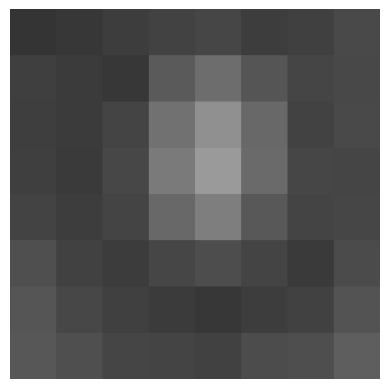

In [33]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('Images/0_2_image.png')
assert img is not None, "file could not be read, check with os.path.exists()"

plt.imshow(img)
plt.axis("off")
plt.show()

In [34]:
hist = cv2.calcHist([img], [0], None, [256],[0,256])
hist.shape

(256, 1)

hist is a 256x1 array, each value corresponds to number of pixels in that image with its corresponding pixel value.

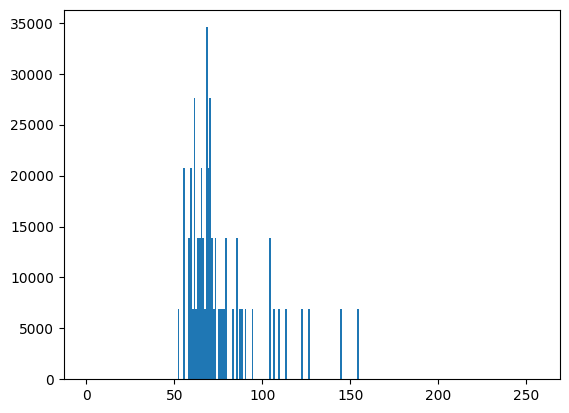

In [35]:
plt.hist(img.ravel(), 256, [0,256])
plt.show()

## **2. Histogram Calculation in Numpy**

Numpy also provides you a function, np.histogram(). So instead of calcHist() function, you can try below line :

In [36]:
import numpy as np 

hist,bins = np.histogram(img.ravel(),256,[0,256])
hist.shape

(256,)

In [37]:
bins.shape

(257,)

`hist` is the same as what we calculated before.  
However, the **bins** array will contain **257 elements**.  
This happens because NumPy creates bins using the intervals:

- 0 → 0.99  
- 1 → 1.99  
- 2 → 2.99  
- ...  
- 255 → 255.99  

So the final bin edge becomes **256**, which is added at the end of the bins array.

But in image processing, we only care about intensity values **0 to 255**,  
so the extra value **256** at the end is not needed.  
Using values up to **255** is sufficient.

> `OpenCV` function is faster than (around 40X) than `np.histogram()`. So stick with OpenCV function.

Or you can use normal plot of matplotlib, which would be good for BGR plot. For that, you need to find the histogram data first. Try below code:

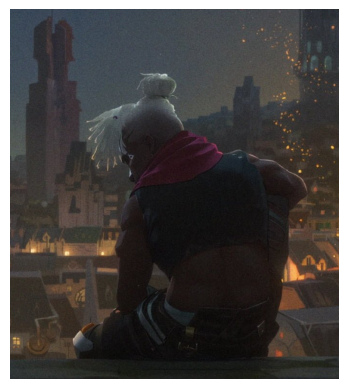

In [38]:
img3 = cv2.imread('Images/0_3_image.png', cv2.IMREAD_COLOR_RGB)
assert img3 is not None, "file could not be read, check with os.path.exists()"

plt.imshow(img3)
plt.axis("off")
plt.show()

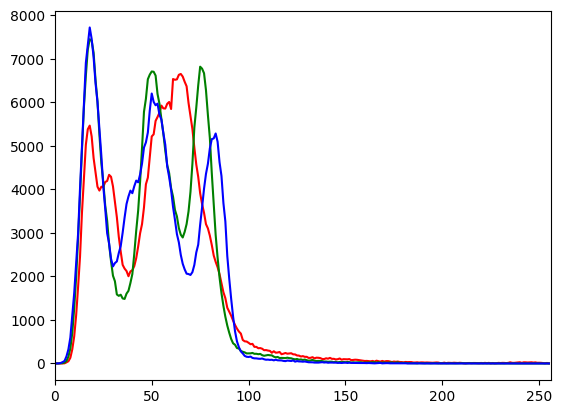

In [39]:
color = ('r','g','b')
for i, col in enumerate(color):
    histr = cv2.calcHist([img3],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.show()